# Week 4 Normal distribution and probability density functions using R

> by Lei Ding, Updated Mar. 2025

In [1]:
# 准备
#install.packages('tigerstats')
#install.packages('moments')

## 1. 概率

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2



[1] 0.03987761

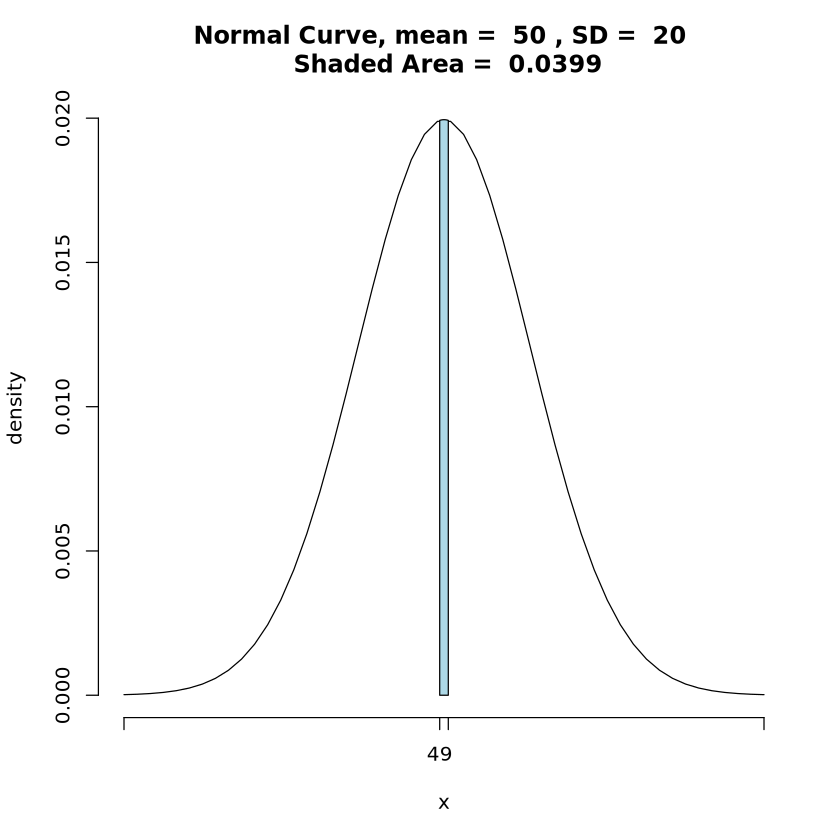

In [2]:
# 1. 概率的估计
tigerstats::pnormGC(c(49, 51), region="between", mean=50, sd=20, graph=TRUE)

[1] 0.5

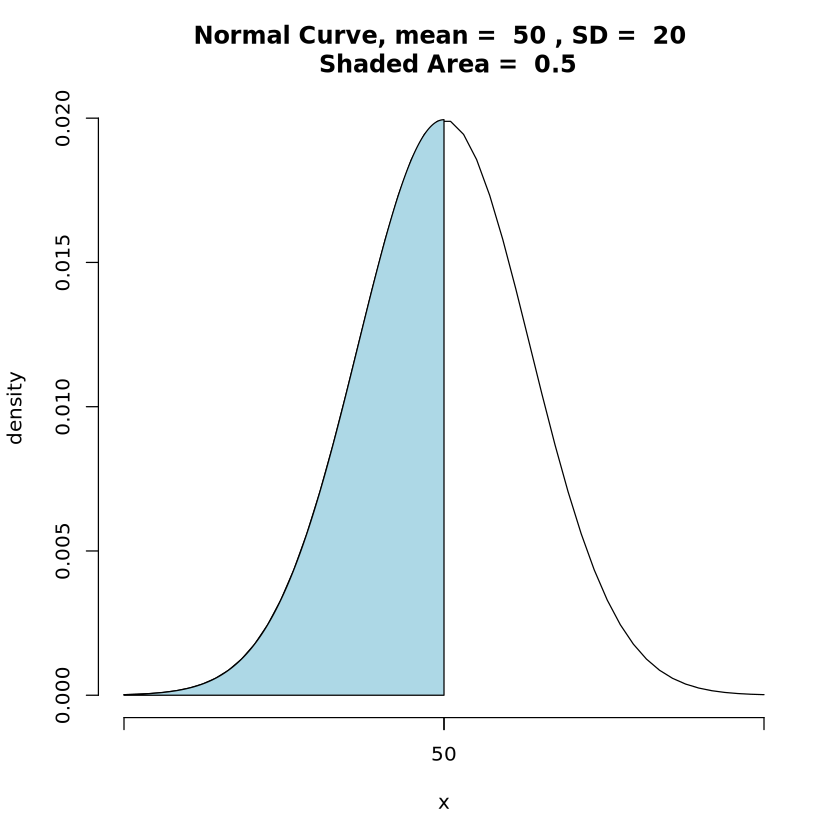

In [3]:
tigerstats::pnormGC(c(50), region="below", mean=50, sd=20, graph=TRUE)

In [4]:
# 2. 累积概率
pnorm(30, 50, 20)
pnorm(q=30, mean=50, sd=20)
pnorm(q=30, mean=50, sd=20, lower.tail=FALSE)  # 右侧

[1] 0.1586553

[1] 0.1586553

[1] 0.8413447

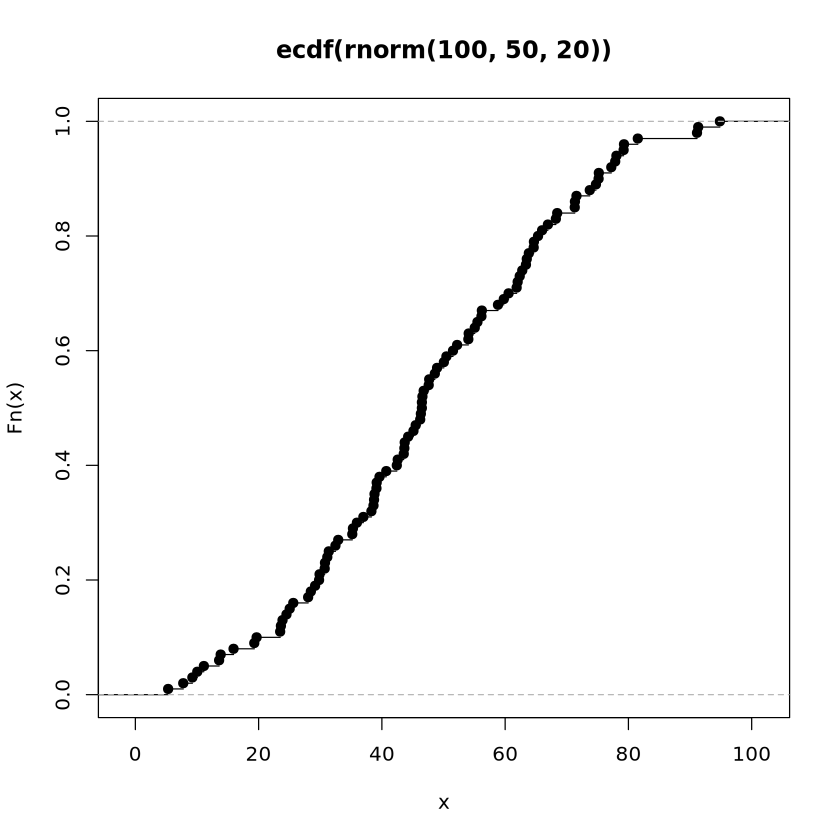

In [5]:
# 3. 经验分布函数，即样本的分布函数
plot(ecdf(rnorm(100, 50, 20)))

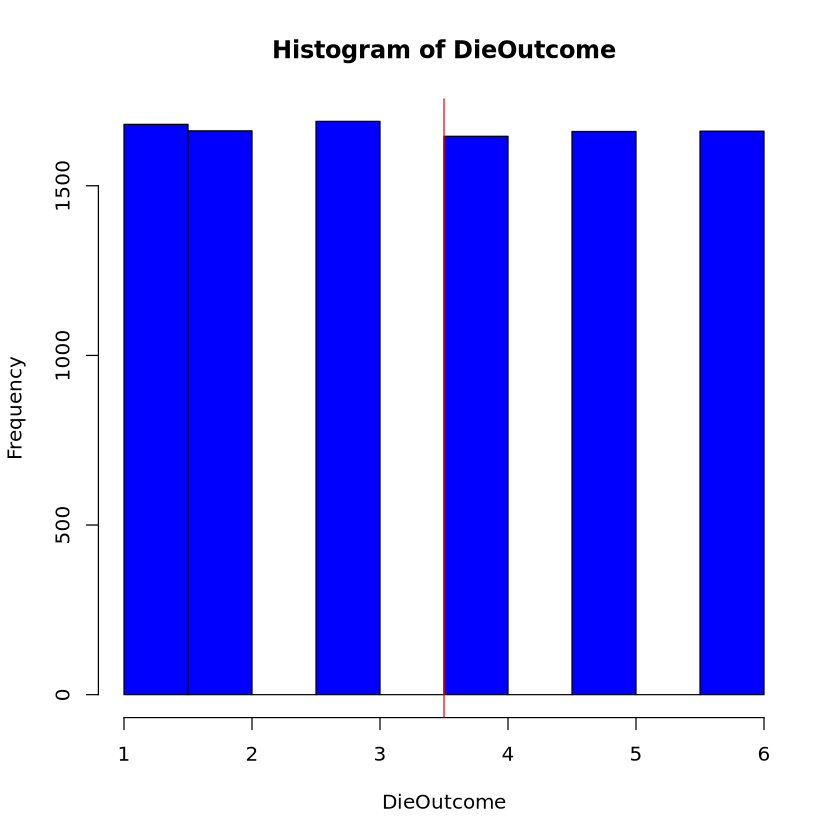

In [6]:
# 4. 扔1个骰子
DieOutcome <- sample(1:6, 10000, replace=TRUE)  # 重复10000次
hist(DieOutcome, col='blue')
abline(v=3.5, col='red', lty=1)  # 添加一条竖线

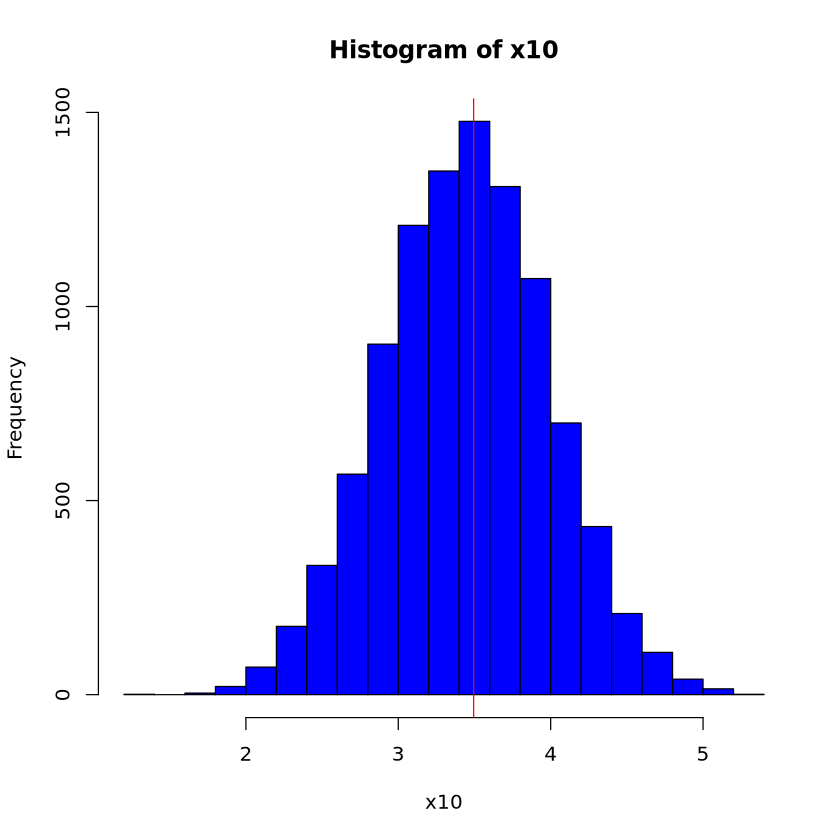

In [7]:
# 5. 模拟扔10个骰子实验
x10 <- c()
k = 10000  # 重复10000次
for (i in 1:k) {x10[i] = mean(sample(1:6, 10, replace=TRUE))}
hist(x10, col='blue')
abline(v=mean(x10), col='red')

## 2. 正态分布

In [8]:
# 6. 分布相关的函数
dnorm(0)  # 概率密度函数
pnorm(2)  # 概率分布函数
pnorm(2, mean=5, sd=3, lower.tail=FALSE)
qnorm(pnorm(2.3))  # 分位数函数

[1] 0.3989423

[1] 0.9772499

[1] 0.8413447

[1] 2.3

In [9]:
# 正态分布样本
x <- rnorm(10)
summary(x)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-0.6174  0.3257  0.4183  0.5972  1.0829  1.8061 

In [10]:
x <- rnorm(10, 20, 2)
summary(x)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  18.46   19.94   20.32   20.19   20.46   22.12 

In [11]:
# 复习: 随机数种子
set.seed(1)
rnorm(5)
rnorm(5)
set.seed(1)
rnorm(5)

[1] -0.6264538  0.1836433 -0.8356286  1.5952808  0.3295078

[1] -0.8204684  0.4874291  0.7383247  0.5757814 -0.3053884

[1] -0.6264538  0.1836433 -0.8356286  1.5952808  0.3295078

In [12]:
# 复习: 抽样
x <- rnorm(10, 20, 2)
x
sample(x, 4)
sample(1:10, 10, replace=TRUE)

[1] 18.35906 20.97486 21.47665 21.15156 19.38922 23.02356 20.77969 18.75752
 [9] 15.57060 22.24986

[1] 22.24986 15.57060 21.15156 20.77969

[1]  1  4  3  6 10 10  6  4  4 10

In [13]:
# 7. 峰度与偏度
time <- c(19.09, 19.55, 17.89, 17.73, 25.15, 27.27, 25.24, 21.05, 21.65, 20.92, 22.61, 15.71, 22.04, 22.60, 24.25)
moments::skewness(time)
moments::kurtosis(time)

[1] -0.01565162

[1] 2.301051

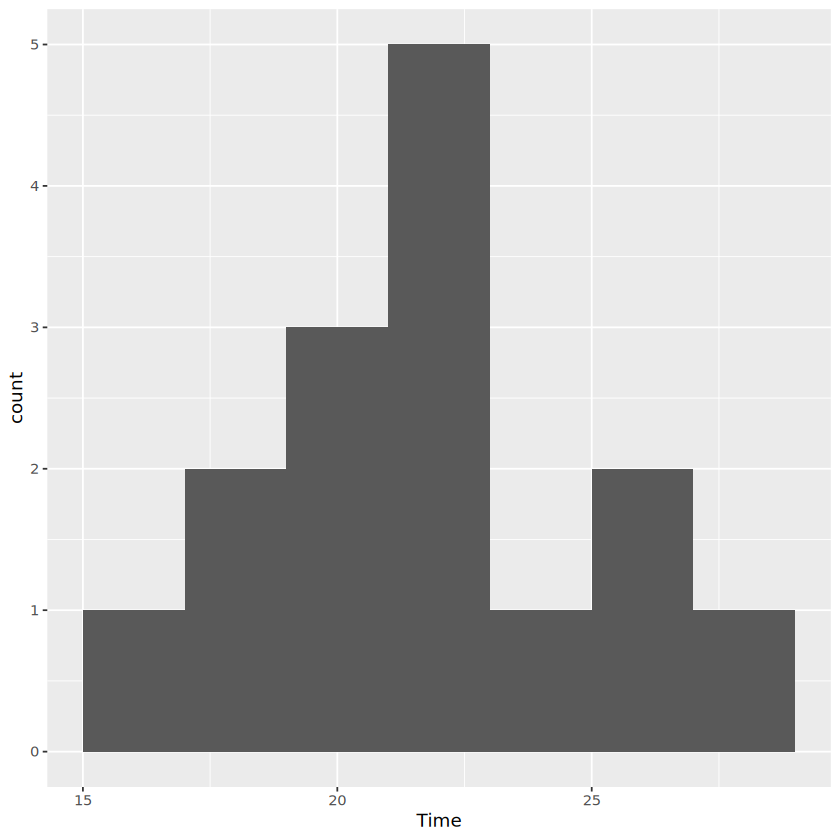

In [14]:
library(ggplot2)
ggplot(data.frame(time), aes(x=time)) + geom_histogram(binwidth=2) + xlab('Time')

In [15]:
# 8. 练习: 正态随机样本的数据分析
firstrun <- rnorm(99, 30, 10)
secondrun <- firstrun + rnorm(99, 5, 2)
finalrun <- secondrun + rnorm(99, 7, 3)
run <- data.frame(firstrun, secondrun, finalrun)
head(run)

,firstrun,secondrun,finalrun
,<dbl>,<dbl>,<dbl>
1,29.42893,32.82251,40.65850
2,35.03608,37.80855,44.22663
3,40.85769,49.01788,60.74635
4,23.09046,31.08610,33.65946
5,17.15401,22.67930,29.24547
6,30.46726,33.00146,37.14185


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  7.761  23.508  29.890  29.850  35.865  54.414 

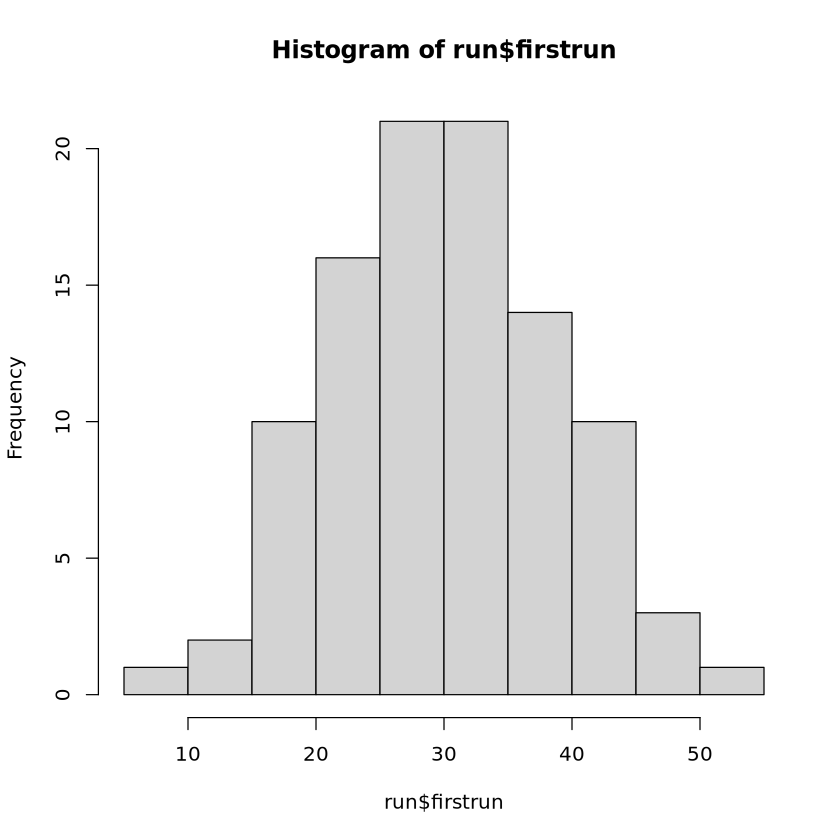

In [16]:
# 9. 摘要
summary(run$firstrun)
hist(run$firstrun)

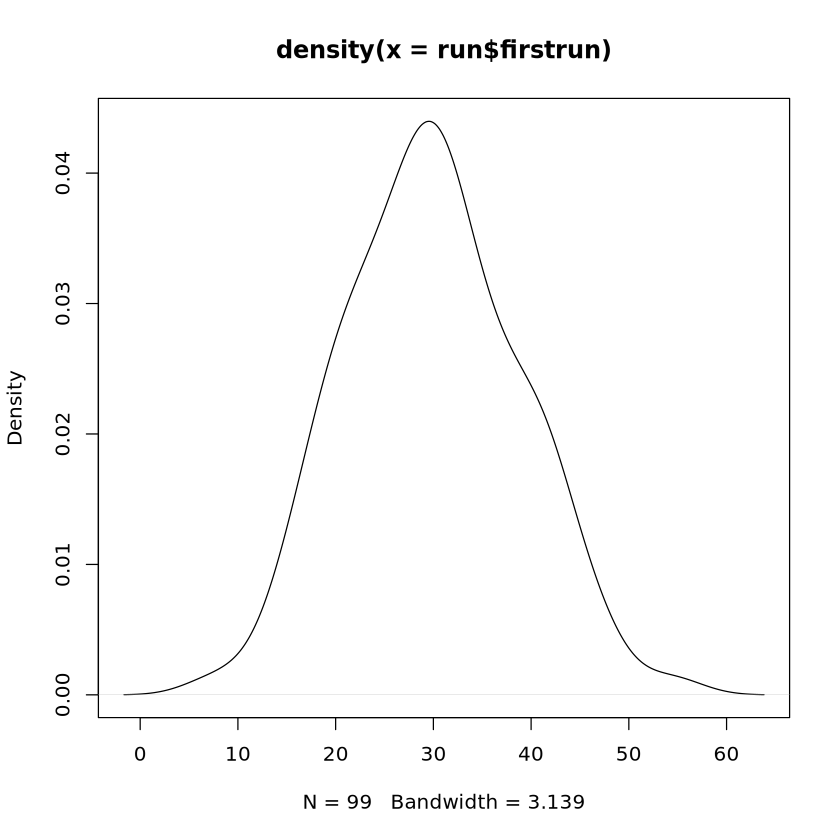

In [17]:
# 10. 概率密度
dens <- density(run$firstrun)
plot(dens)

In [18]:
# 11. Shapiro-Wilk检验: 正态性检验
shapiro.test(run$firstrun)


	Shapiro-Wilk normality test

data:  run$firstrun
W = 0.99453, p-value = 0.9625


In [19]:
shapiro.test(1:99)  # 不服从正态分布，拒绝假设


	Shapiro-Wilk normality test

data:  1:99
W = 0.95473, p-value = 0.001838


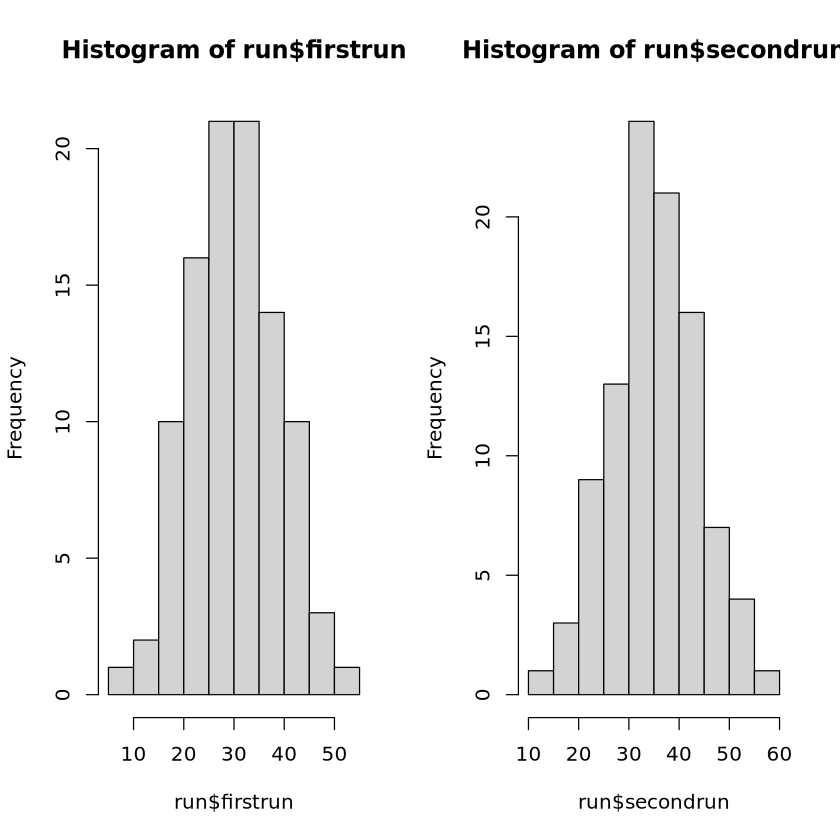

In [20]:
# 12. 前两组数据分析: 绘制直方图
par(mfrow=c(1, 2))
hist(run$firstrun)
hist(run$secondrun)

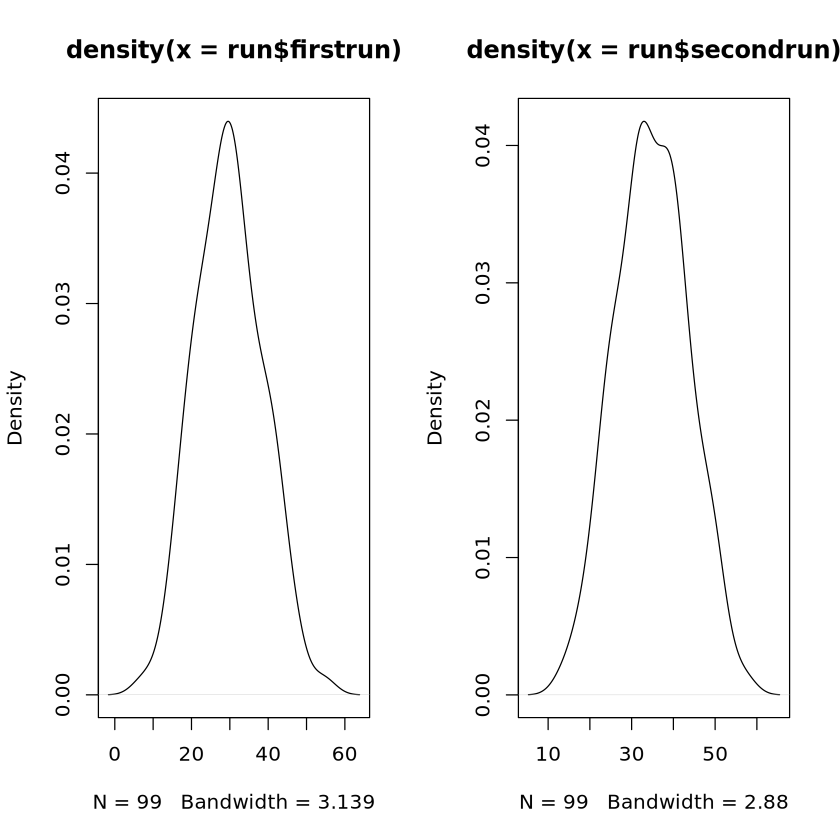

In [21]:
# 13. 前两组数据分析: 绘制密度图
par(mfrow=c(1, 2))
plot(density(run$firstrun))
plot(density(run$secondrun))

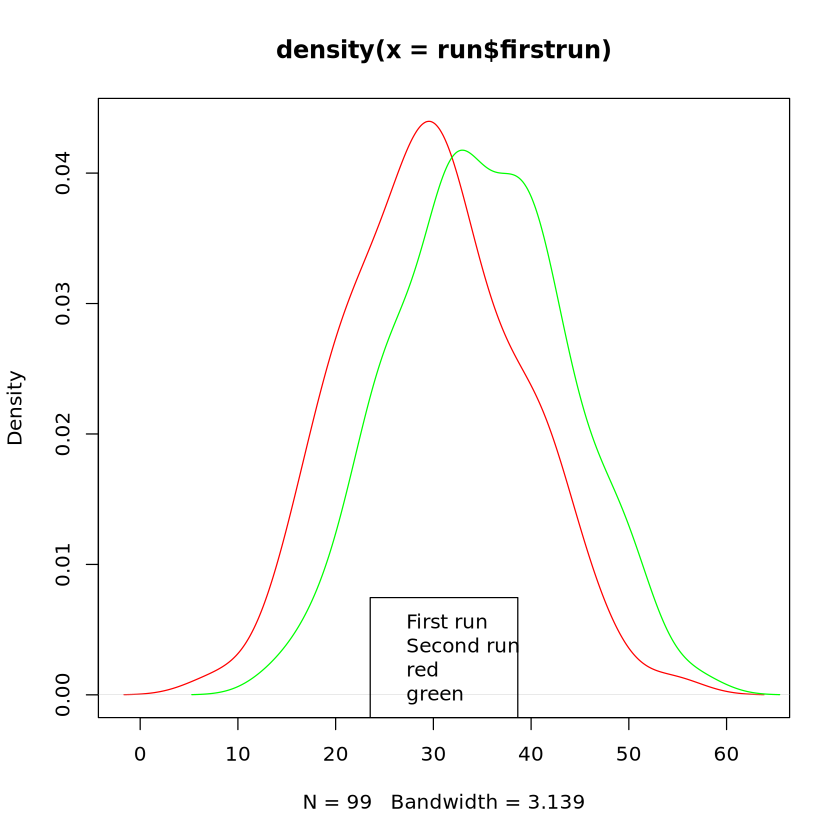

In [22]:
# 14. 前两组数据分析: 密度图绘制到同一幅图中
plot(density(run$firstrun), col='red')
lines(density(run$secondrun), col='green')
legend('bottom', legend=c('First run', 'Second run', fill=c('red', 'green')))

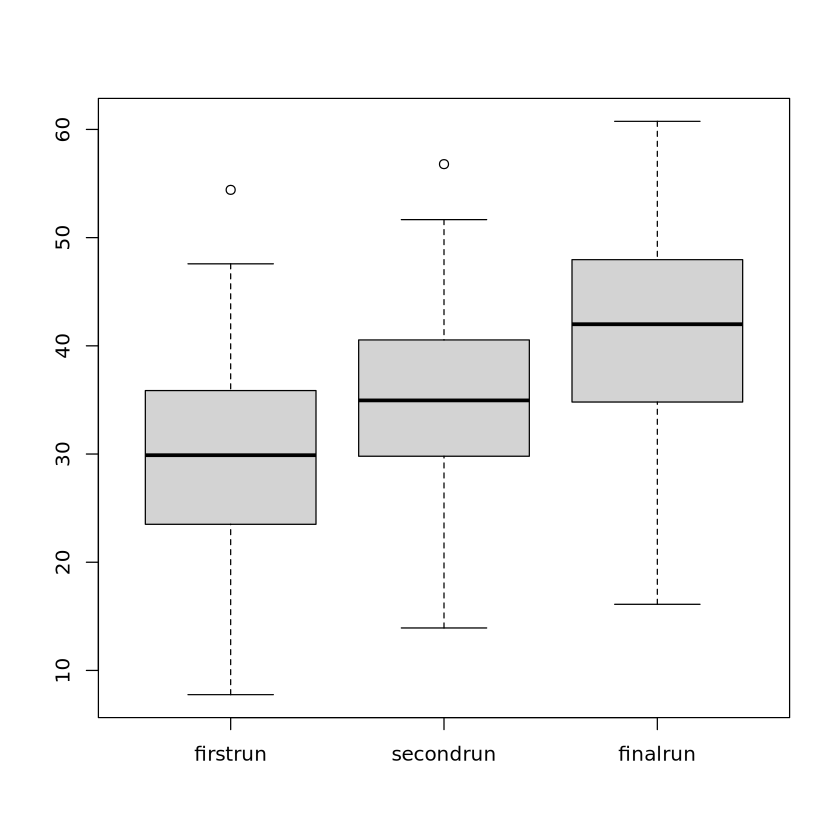

In [23]:
# 15. 比较三组数据的分布情况
boxplot(run)

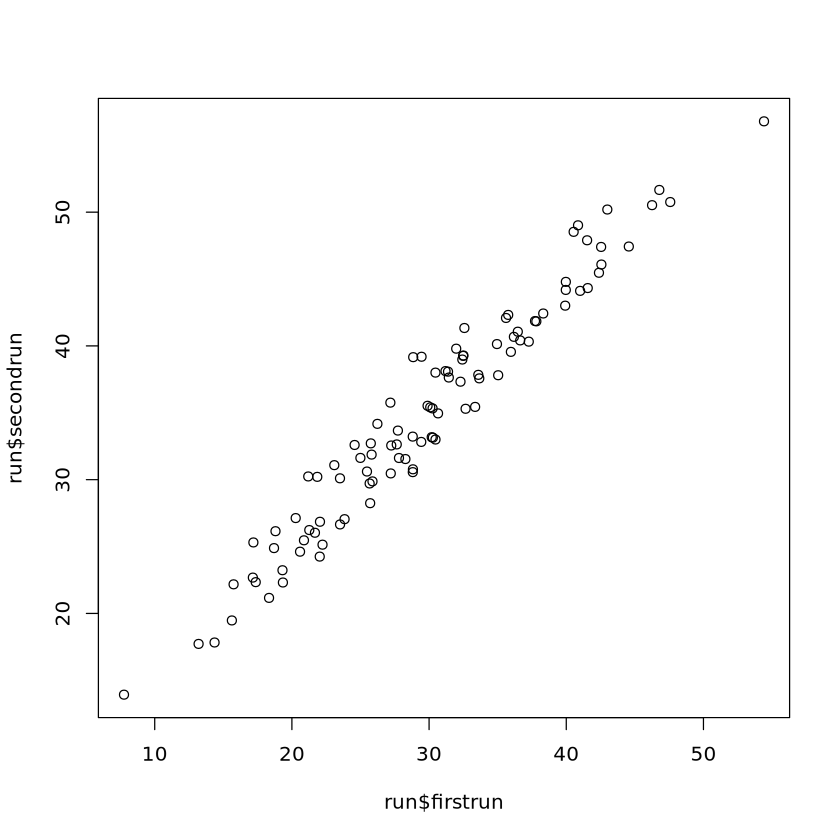

In [24]:
# 16. 比较前两组数据: 散点图
plot(run$firstrun, run$secondrun)

## 3. 二项分布与泊松分布

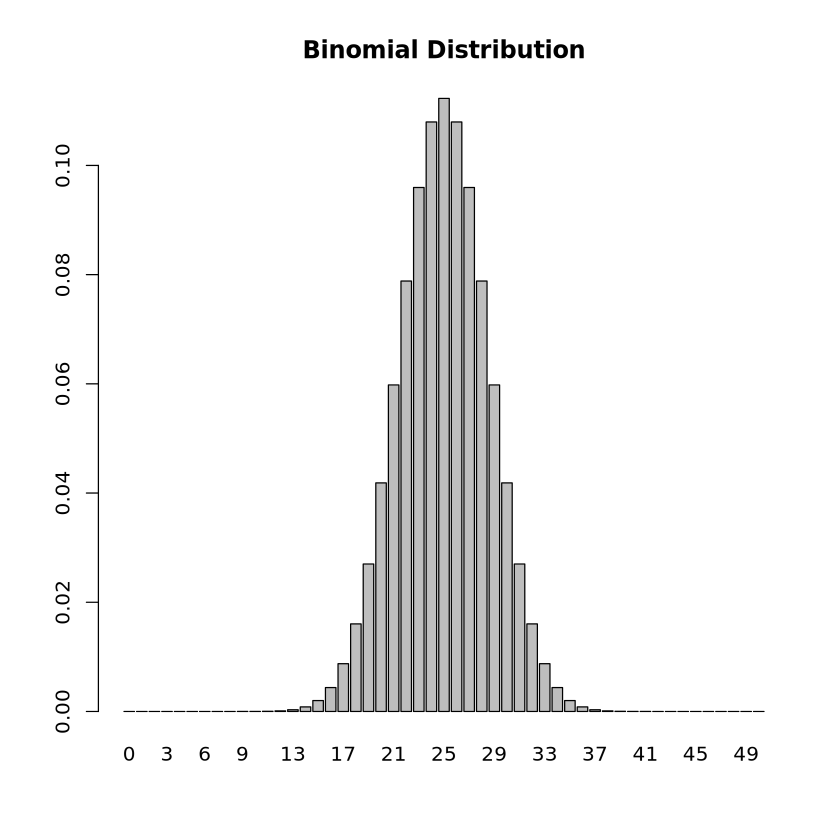

In [25]:
# 17. 二项分布
x <- 0:50
prob <- dbinom(x, 50, 0.5)
barplot(prob, names.arg=x, main='Binomial Distribution')

In [26]:
# 18. 二项分布的偏度
moments::kurtosis(rbinom(1000, 50, 0.1))  # 非偏态
moments::kurtosis(rbinom(1000, 50, 0.7))

[1] 3.12507

[1] 2.99032

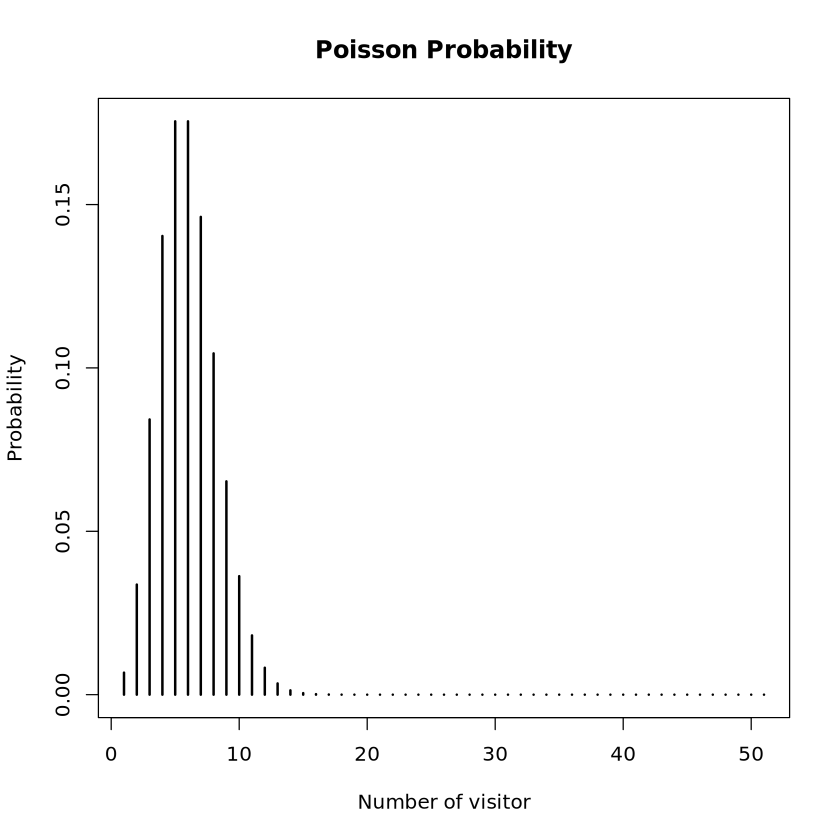

In [27]:
# 19. 泊松分布
plot(dpois(0:50, 5), type='h', lwd=2, main='Poisson Probability', xlab='Number of visitor', ylab='Probability')

In [28]:
# 20. 泊松分布的累积分布函数
ppois(60, lambda=50)
ppois(45, lambda=50, lower.tail=FALSE)

[1] 0.9278398

[1] 0.7331335